# Gradient Descent and Variations

# Problem 1, Part a
Solve the optimization using the gradient descent method with exact line search. Plot the sequence of solutions x^k

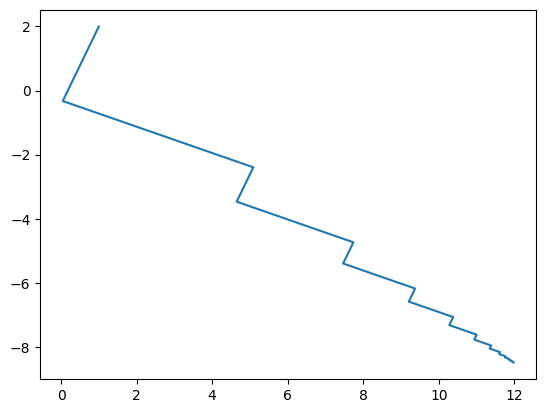

In [1]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

def f(P, q, x):
  term1 = 0.5 * np.dot(x.T, np.dot(P, x))
  term2 = np.dot(q.T, x)
  term3 = np.log(np.exp(-2 * x[0]) + np.exp(-x[1]))
  return term1 + term2 + term3

def grad_f(P, q, x):
  term12 = np.dot(P, x) + q
  term3 = (1/ (np.exp(-2 * x[0]) + np.exp(-x[1]))) * np.array([-2 * np.exp(-2 * x[0]), -np.exp(-x[1])])
  return term12 + term3

def exact_line_search(P, q, x, d):

  def line_function(alpha):
    return f(P, q, x + alpha * d)

  final_alpha = opt.minimize_scalar(line_function).x

  return final_alpha

# Starting x^k where k = 0
x_k = np.array([1, 2])
P = np.array([[3, 4], [4, 6]])
q = np.array([-2, 4])
result_list = [x_k]
# print(f(P, q, x_k))

# d = -grad_f(P, q, x_k)
# alpha = exact_line_search(P, q, x_k, d)
# x_k = x_k + alpha * d
# print(x_k)

stop_condition = 0.01
norm_of_grad_f = 1

while norm_of_grad_f > stop_condition:
  d = -grad_f(P, q, x_k)
  alpha = exact_line_search(P, q, x_k, d)
  x_k = x_k + alpha * d
  result_list.append(x_k)
  norm_of_grad_f = np.linalg.norm(grad_f(P, q, x_k))

# print(result_list)

xlist = [x[0] for x in result_list]
ylist = [x[1] for x in result_list]
plt.plot(xlist, ylist)
plt.show()

# Problem 1, Part b
Solve the optimization using the gradient descent method with backtracking line search with the parameter α_init = 0.15, γ = 0.7, and β = 0.8. Plot the sequence of solutions x^k.

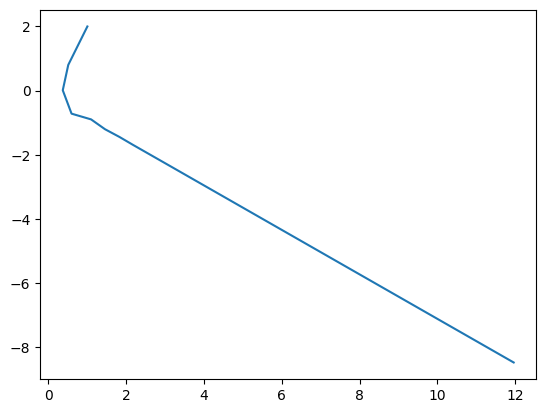

In [2]:
# Only need new backtracking line search function, the f(x) and grad_f() are still the same.
def backtracking_line_search(P, q, x, d, alpha=0.15, gamma=0.7, beta=0.8):
  while f(P, q, x + alpha * d) > f(P, q, x) + gamma * alpha * np.dot(grad_f(P, q, x).T, d):
    alpha *= beta
  return alpha


x_k = np.array([1, 2])
result_list = [x_k]
norm_of_grad_f = 1

while norm_of_grad_f > stop_condition:
  d = -grad_f(P, q, x_k)
  alpha = backtracking_line_search(P, q, x_k, d)
  x_k = x_k + alpha * d
  result_list.append(x_k)
  norm_of_grad_f = np.linalg.norm(grad_f(P, q, x_k))

xlist = [x[0] for x in result_list]
ylist = [x[1] for x in result_list]
plt.plot(xlist, ylist)
plt.show()

# Problem 2, Part a
Repeat the same exact line search, but this time with a new matrix P.

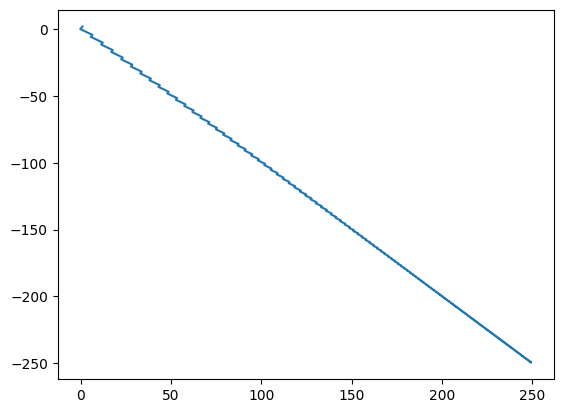

In [3]:
x_k = np.array([1, 2])
P_new = np.array([[5.005, 4.995], [4.995, 5.005]])
result_list = [x_k]
norm_of_grad_f = 1

while norm_of_grad_f > stop_condition:
  d = -grad_f(P_new, q, x_k)
  alpha = exact_line_search(P_new, q, x_k, d)
  x_k = x_k + alpha * d
  result_list.append(x_k)
  norm_of_grad_f = np.linalg.norm(grad_f(P_new, q, x_k))

# print(result_list)

xlist = [x[0] for x in result_list]
ylist = [x[1] for x in result_list]
plt.plot(xlist, ylist)
plt.show()

# Problem 2, Part b
Repeat the same backtracking line search, but this time with a new matrix P.

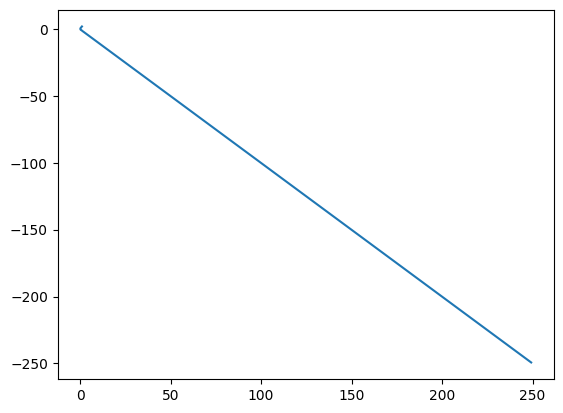

In [4]:
x_k = np.array([1, 2])
result_list = [x_k]
norm_of_grad_f = 1

while norm_of_grad_f > stop_condition:
  d = -grad_f(P_new, q, x_k)
  alpha = backtracking_line_search(P_new, q, x_k, d)
  x_k = x_k + alpha * d
  result_list.append(x_k)
  norm_of_grad_f = np.linalg.norm(grad_f(P_new, q, x_k))

xlist = [x[0] for x in result_list]
ylist = [x[1] for x in result_list]
plt.plot(xlist, ylist)
plt.show()